=== 下载 Baseline 测试图片 ===
下载失败 https://images.unsplash.com/photo-1581091226825-a6a63e27c4df: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1581091226825-a6a63e27c4df

=== 初始化 YOLO 模型 ===
[YOLO] 正在热身...
[YOLO] 模型加载并热身完成 (设备: cuda)

=== 开始 Baseline 推理测试 ===

处理: img_00.jpg | 形状: (853, 1280, 3)


/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35782 (\N{CJK UNIFIED IDEOGRAPH-8BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/

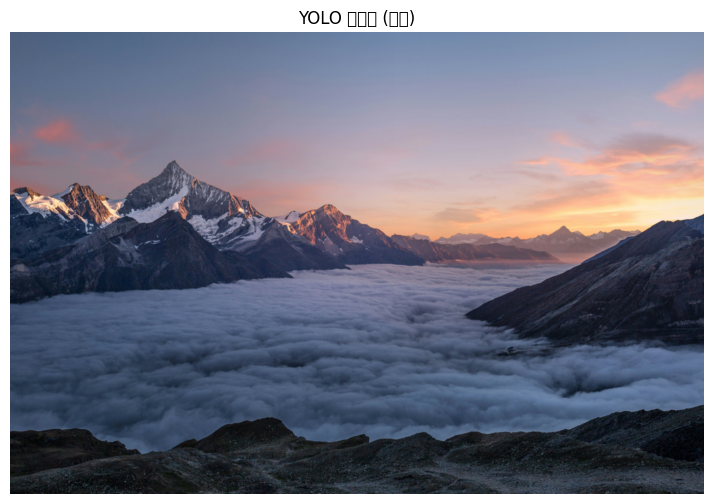

/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


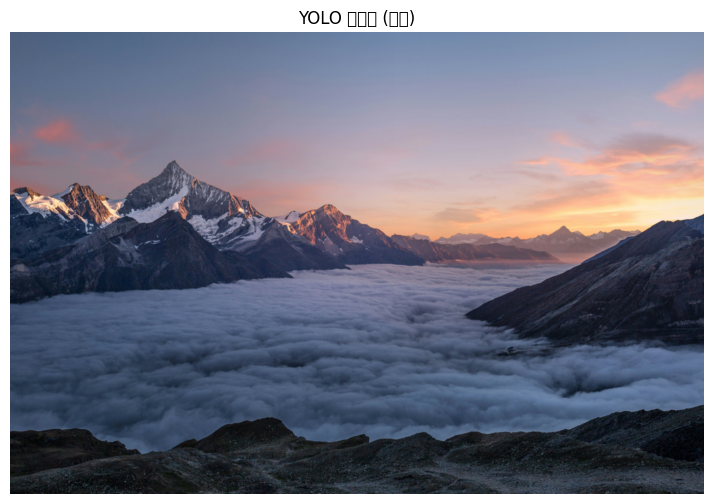

  -> 结果: 检测到 0 个目标, 耗时 49.5ms

处理: img_02.jpg | 形状: (853, 1280, 3)


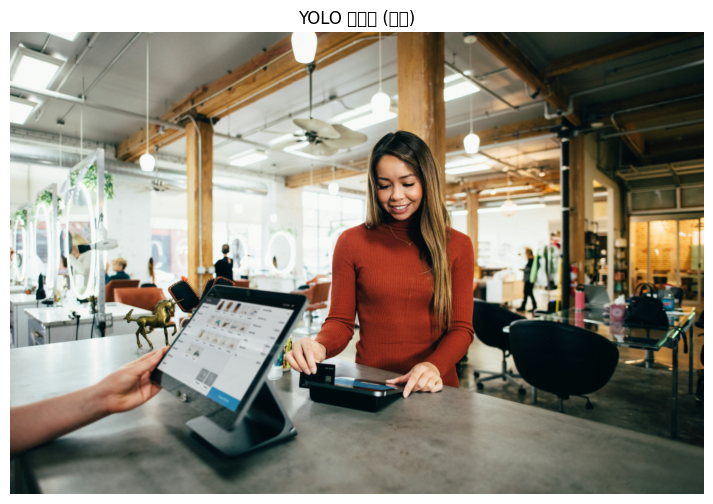

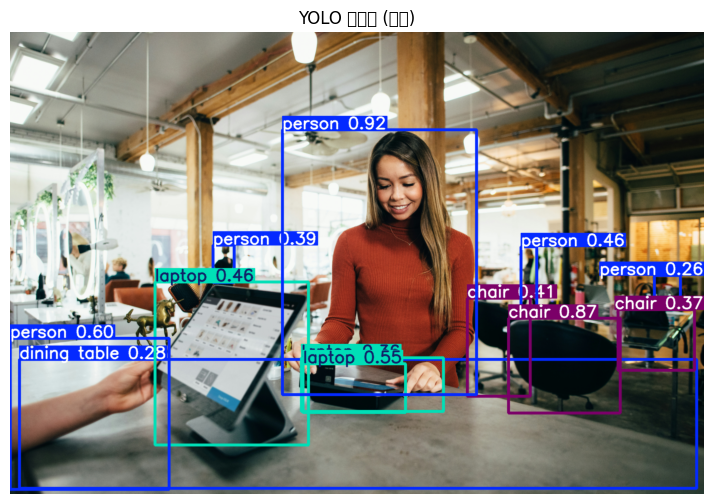

  -> 结果: 检测到 12 个目标, 耗时 16.4ms


In [1]:
import os
import requests
import numpy as np
from PIL import Image
from detector import YOLODetector

# ---------- 配置 ----------
BASELINE_IMAGE_URLS = [
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4",  # 咖啡店场景
    "https://images.unsplash.com/photo-1581091226825-a6a63e27c4df",  # 厨房场景
    "https://images.unsplash.com/photo-1556740738-b6a63e27c4df"   # 办公室场景
]
SAVE_DIR = "./test_baseline_images"
MODEL_PATH = "yolov8n.pt"  # 替换为你的实际路径

# ---------- 工具函数（抄自你的代码） ----------
def download_to_local(url: str, save_path: str) -> bool:
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        with open(save_path, "wb") as f:
            f.write(r.content)
        return True
    except Exception as e:
        print(f"下载失败 {url}: {e}")
        return False

def load_image_from_local(path: str, max_size=1280):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if max(w, h) > max_size:
        scale = max_size / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.BILINEAR)
    # 转 BGR 给 OpenCV 模型使用
    return np.array(img)

# ---------- 主测试流程 ----------
def test_yolo_detector():
    os.makedirs(SAVE_DIR, exist_ok=True)
    
    # 1. 准备 Baseline 图片
    print("=== 下载 Baseline 测试图片 ===")
    local_paths = []
    for i, url in enumerate(BASELINE_IMAGE_URLS):
        fname = f"img_{i:02d}.jpg"
        path = os.path.join(SAVE_DIR, fname)
        if os.path.isfile(path):
            local_paths.append(path)
            continue
        if download_to_local(url, path):
            local_paths.append(path)

    # 2. 初始化模型
    print("\n=== 初始化 YOLO 模型 ===")
    detector = YOLODetector(MODEL_PATH)

    # 3. 逐张推理
    print("\n=== 开始 Baseline 推理测试 ===")
    for path in local_paths:
        img_np = load_image_from_local(path)
        print(f"\n处理: {os.path.basename(path)} | 形状: {img_np.shape}")
        
        detector.show_image(img_np, title="YOLO 识别前 (原图)")
        result = detector.detect(img_np)
        detector.show_image(result["annotated_image"], title="YOLO 识别后 (结果)")
        
        if result["status"] == "success":
            boxes = result["boxes"]
            n = len(boxes) if boxes is not None else 0
            print(f"  -> 结果: 检测到 {n} 个目标, 耗时 {result['inference_time_ms']:.1f}ms")
        else:
            print(f"  -> 失败: {result['detail']}")

if __name__ == "__main__":
    test_yolo_detector()
